In [165]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import r2_score

In [87]:
df = pd.read_csv("house-prices-tp.csv")
df.info()
df

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.071510,0.000000,4.490000,0.0,0.449,6.121000,56.8,3.747600,3.000000,247.000000,18.500000,395.150000,8.440000,22.200000
1,0.082650,0.000000,13.920000,0.0,0.437,6.127000,18.4,5.502700,4.000000,289.000000,16.000000,396.900000,8.580000,23.900000
2,0.128160,12.500000,6.070000,0.0,0.409,5.885000,33.0,6.498000,4.000000,345.000000,18.900000,396.900000,8.790000,20.900000
3,0.088730,21.000000,5.640000,0.0,0.439,5.963000,45.7,6.814700,4.000000,243.000000,16.800000,395.560000,13.450000,19.700000
4,0.114320,0.000000,8.560000,0.0,0.520,6.781000,71.3,2.856100,5.000000,384.000000,20.900000,395.580000,7.670000,26.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551,0.082440,30.000000,4.930000,0.0,0.428,6.481000,18.5,6.189900,6.000000,300.000000,16.600000,379.410000,6.360000,23.700000
552,0.475470,0.000000,9.900000,0.0,0.544,6.113000,58.8,4.001900,4.000000,304.000000,18.400000,396.230000,12.730000,21.000000
553,0.249800,0.000000,21.890000,0.0,0.624,5.857000,98.2,1.668600,4.000000,437.000000,21.200000,392.040000,21.320000,13.300000
554,32.504013,6.528591,8.937346,1.0,NaN,4.016588,NaN,5.243777,20.416908,197.236588,19.639059,6.267059,7.033962,23.028798


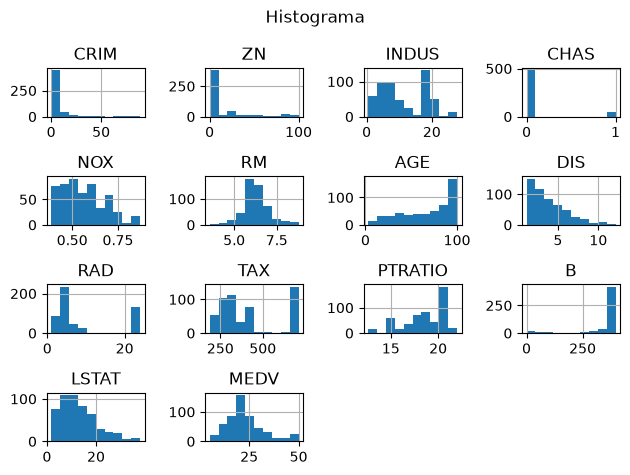

In [100]:
#No hace falta correr, es para ver todos los histogramas de las variables.
df.hist()
plt.suptitle('Histograma')
plt.tight_layout()
plt.show()

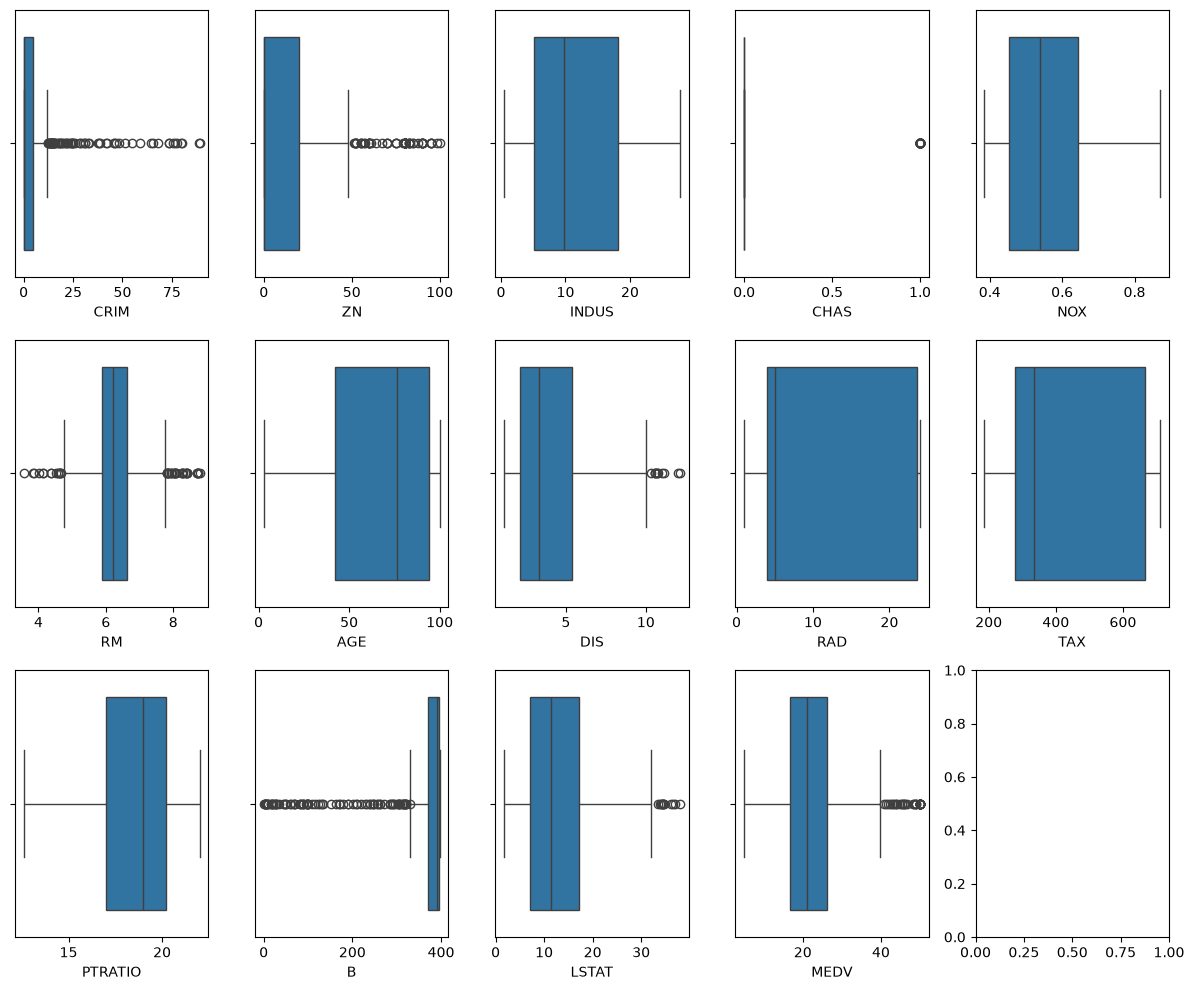

In [89]:
cols = df.columns
fig, axes = plt.subplots(nrows=3, ncols=5, sharey=False, figsize=(12, 10))
for i, col in enumerate(cols, 1): sns.boxplot(data=df, x=col, ax=axes.flatten()[i-1])
plt.tight_layout()
plt.show()

Despues de un analisis en conjunto entre los datos y las descripciones de las variables llegamos a la conclusion de que CHAS es la unica variable a cambiar de tipo.
Notamos que existen muchos outliers, pero nos recomendaron mantenerlos, porque aportan mucha informacion.
Tambien existen algunos datos faltantes en el dataset

In [90]:
df.isna().mean() * 100

CRIM       4.136691
ZN         3.956835
INDUS      2.697842
CHAS       4.136691
NOX        4.316547
RM         3.776978
AGE        4.316547
DIS        2.697842
RAD        5.035971
TAX        3.237410
PTRATIO    5.035971
B          3.956835
LSTAT      3.956835
MEDV       3.776978
dtype: float64

Revisamos el porcentaje de NaN por variables para tomar la decision de si eliminar filas de datos.

In [91]:
filas_iniciales = len(df)

porcentaje_nan_por_fila = df.isna().mean(axis=1)
df = df.loc[porcentaje_nan_por_fila <= 0.30].copy()

filas_eliminadas = filas_iniciales - len(df)
print(f"Filas eliminadas: {filas_eliminadas}")
print(f"Filas restantes: {len(df)}")
print(f"Porcentaje de filas eliminadas: {filas_eliminadas / filas_iniciales * 100:.2f}%")

Filas eliminadas: 28
Filas restantes: 528
Porcentaje de filas eliminadas: 5.04%


Removimos todas aquellas filas que tengan mas o un 30% de sus datos como NaN, nos parecio corrector este porcentaje ya que representan un 5% de los datos, esta en el limite de lo permitido.

In [92]:
porcentaje_nan = df.isna().mean() * 100
porcentaje_nan.sort_values()

INDUS      0.000000
DIS        0.378788
LSTAT      0.378788
NOX        0.568182
RM         0.568182
MEDV       0.568182
B          0.568182
CHAS       0.568182
TAX        0.757576
CRIM       0.946970
PTRATIO    1.136364
ZN         1.136364
AGE        1.515152
RAD        1.515152
dtype: float64

El procentaje de NaN en las variables despues de la limpieza es muy pequeña, por lo que podemos imputar datos sin que se consideren datos sinteticos.

In [95]:
df = df.fillna(df.median())

Reemplazamos todos aquellos valores faltantes por la mediana de cada variable.

In [96]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
Index: 528 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     528 non-null    float64
 1   ZN       528 non-null    float64
 2   INDUS    528 non-null    float64
 3   CHAS     528 non-null    float64
 4   NOX      528 non-null    float64
 5   RM       528 non-null    float64
 6   AGE      528 non-null    float64
 7   DIS      528 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      528 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        528 non-null    float64
 12  LSTAT    528 non-null    float64
 13  MEDV     528 non-null    float64
dtypes: float64(14)
memory usage: 61.9 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000
mean,5.007176,12.261131,11.236754,0.087121,0.559012,6.283307,68.003000,3.880434,9.557407,409.411470,18.445231,351.185586,12.891600,22.670369
std,12.146422,24.111924,6.909106,0.282280,0.118495,0.756884,28.171048,2.184309,8.632460,167.350774,2.171376,96.938585,7.439694,9.327546
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.083827,0.000000,5.175000,0.000000,0.453000,5.877750,43.250000,2.110500,4.000000,280.511366,17.375000,371.990000,7.135000,16.950000
50%,0.289600,0.000000,9.690000,0.000000,0.538000,6.208000,76.600000,3.304487,5.000000,334.500000,19.000000,390.950000,11.395000,21.200000
75%,4.452190,20.000000,18.100000,0.000000,0.631720,6.630250,93.800000,5.255350,22.746235,666.000000,20.200000,396.007500,17.127500,25.125000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
#Utilizamos el metodo skew para ver la asimetria de las variables.
df.skew(numeric_only=True)

CRIM       4.196731
ZN         2.085877
INDUS      0.293200
CHAS       2.936436
NOX        0.700882
RM         0.326380
AGE       -0.575311
DIS        1.055636
RAD        0.999665
TAX        0.649373
PTRATIO   -0.811087
B         -2.582387
LSTAT      0.947417
MEDV       1.087243
dtype: float64

Analisis de las variables mediante el uso del dataset limpio (estructura del analisis tomada de los ejemplos de Mineria de Datos).

CRIM (tasa de criminalidad per cápita)
    Media: 5.01 | Mediana: 0.29.
    Rango: 0.006 - 88.98. Desviación estándar: 12.15 (mayor que la propia media).
    Asimetría muy fuerte (skew = 4.20): la mayoría de las ciudades tiene criminalidad casi nula, pero un puñado de zonas muy peligrosas dispara el promedio muy por encima de la mediana.

ZN (proporción de terrenos residenciales en lotes grandes)
    Media: 12.26 | Mediana: 0.00.
    Rango: 0 - 100. Desviación estándar: 24.11.
    Asimetría alta (skew = 2.09): más de la mitad de las ciudades tiene ZN = 0 (nada de lotes grandes), por eso la mediana es directamente 0, mientras que algunas zonas totalmente residenciales de baja densidad llevan la media hacia arriba.

INDUS (proporción de acres de negocio no minorista)
    Media: 11.24 | Mediana: 9.69.
    Rango: 0.46 - 27.74. Desviación estándar: 6.91.
    Media y mediana cercanas y skew bajo (0.29): distribución razonablemente simétrica, sin outliers extremos.

CHAS (limitantes con el río Charles)
    Es binaria (0/1), alrededor del 8.7% limitan con el río.

NOX (concentración de óxidos de nitrógeno)
    Media: 0.559 | Mediana: 0.538.
    Rango: 0.385 - 0.871. Desviación estándar: 0.119.
    Asimetría moderada (skew = 0.70): hay más zonas con niveles de contaminación bajos-medios, con una cola de barrios más industriales/contaminados que empuja la media hacia arriba.

RM (habitaciones promedio por vivienda)
    Media: 6.28 | Mediana: 6.21.
    Rango: 3.56 - 8.78. Desviación estándar baja: 0.78.
    Media y mediana casi iguales, es decir, distribución bastante simétrica, sin grandes outliers. Es la variable que más se parece a una normal de todo el dataset.

AGE (% de viviendas ocupadas por dueños, construidas antes de 1940)
    Media: 68.00 | Mediana: 76.60.
    Rango: 2.9 - 100. Desviación estándar: 28.17.
    Asimetría negativa (skew = -0.58): acá la mediana supera a la media. La mayoría de los barrios tiene un parque habitacional bastante antiguo (valores altos), pero un grupo de zonas con construcciones mucho más nuevas arrastra la media hacia abajo.

DIS (distancia ponderada a centros de empleo)
    Media: 3.88 | Mediana: 3.30.
    Rango: 1.13 - 12.13. Desviación estándar: 2.18.
    Asimetría alta (skew = 1.06): la mayoría de las propiedades está relativamente cerca de los centros de empleo, con algunas zonas muy alejadas que generan la cola larga a la derecha.

RAD (índice de accesibilidad a autopistas radiales)
    Media: 9.56 | Mediana: 5.00.
    Rango: 1 - 24. Desviación estándar: 8.63.
    Asimetría marcada (skew = 1.00) y una desviación estándar casi tan grande como la media: esta variable tiene un comportamiento casi bimodal (muchos valores bajos, un salto grande hasta 24), típico de un índice categórico más que continuo.

TAX (tasa de impuesto a la propiedad)
    Media: 409.41 | Mediana: 334.50.
    Rango: 187 - 711. Desviación estándar: 167.35.
    Asimetría moderada (skew = 0.65), coherente con RAD (ambas suelen moverse juntas): hay un grupo de zonas con impuestos mucho más altos que el resto.

PTRATIO (ratio alumno-maestro)
    Media: 18.45 | Mediana: 19.00.
    Rango: 12.6 - 22. Desviación estándar: 2.17.
    Asimetría negativa leve (skew = -0.81): la mayoría de los distritos tiene ratios altos (cercanos al máximo), con algunos distritos con mucha mejor relación alumno-maestro que bajan el promedio.

B (resultado de B = 1000(Bk − 0.63)²)
    Media: 347.81 | Mediana: 390.82.
    Rango: 0.32 - 396.9. Desviación estándar alta: 99.64.
    asimetría negativa marcada (-2.58): acá la mediana supera a la media

LSTAT (% de población de menor estatus socioeconómico)
    Media: 13.03 | Mediana: 11.47.
    Rango: 1.73 - 37.97. Desviación estándar: 7.58.
    Asimetría moderada hacia la derecha: hay más barrios con porcentajes bajos, pero una cola de zonas con LSTAT muy alto que empuja la media hacia arriba.

MEDV (valor mediano de la vivienda, variable target)
    Media: 22.75 k$ | Mediana: 21.20 k$.
    Rango: 5.00 - 50.00 k$. Desviación estándar: 9.49.
    Leve asimetría positiva. El máximo en 50.0 no es casual: es un valor "tope" (censurado) del dataset original de Boston, así que ese pico en 50 concentra más casos de los que esperaríamos en una cola normal.

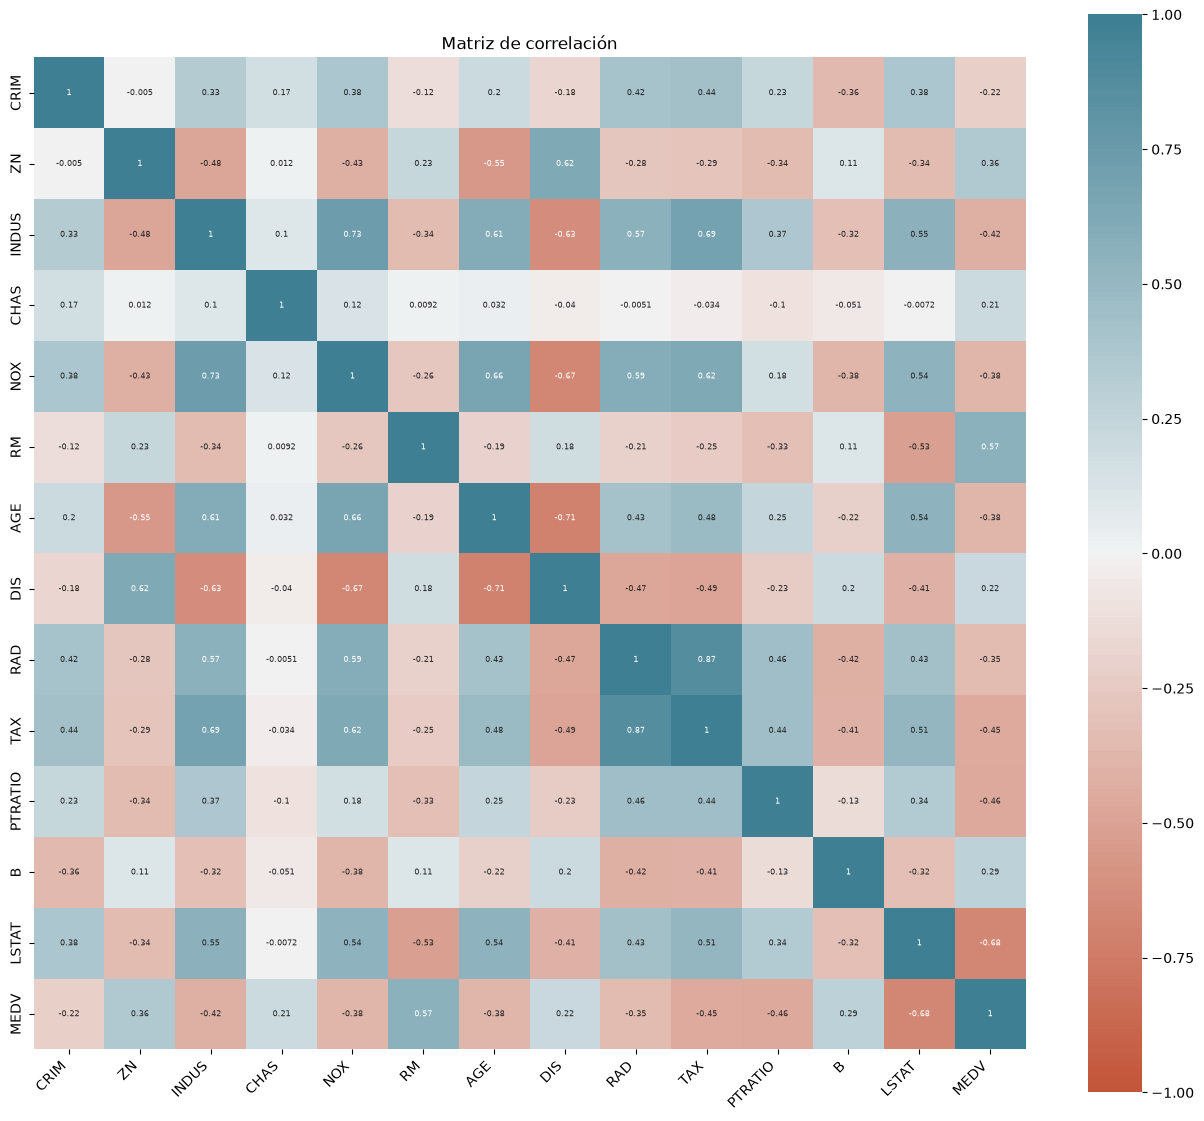

In [104]:
corr = df.corr()
fig, ax = plt.subplots(figsize=(16, 14))
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 6}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.title('Matriz de correlación')
plt.show()

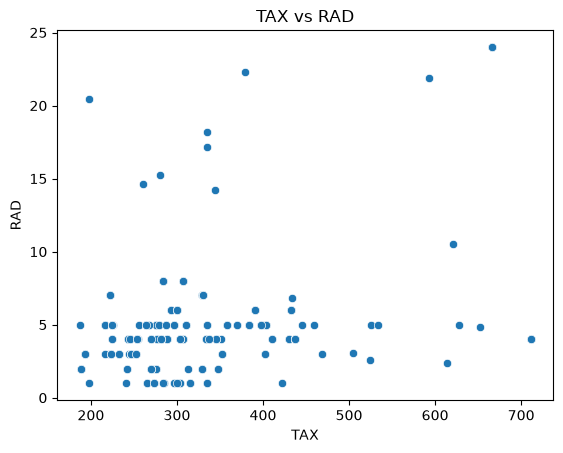

In [111]:
sns.scatterplot(data=df, x='TAX', y='RAD')
plt.title('TAX vs RAD')
plt.show()

Multicolinealidad muy fuerte (0.87) esto nos indica que estas 2 variables independientes explican casi lo mismo. Esto es importante porque utilizar ambas nos va a dificultar la interpretacion de coeficientes y reducir la precision de nuestras estimaciones.
NOX vs INDUS, AGE vs DIS, NOX vs DIS y INDUS vs DIS tambien poseen un indice de correlacion alto pero consideramos que estan dentro de lo permitido.

In [168]:
x = df.drop(columns=['MEDV'])
y = df['MEDV']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [169]:
pipeline = Pipeline([
    ('estandarizacion', StandardScaler()),
    ('modelo', LinearRegression())
])

pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)
print(f"R-cuadrado (R2): {r2_score(y_test, y_pred)}")

R-cuadrado (R2): 0.6471191167073733


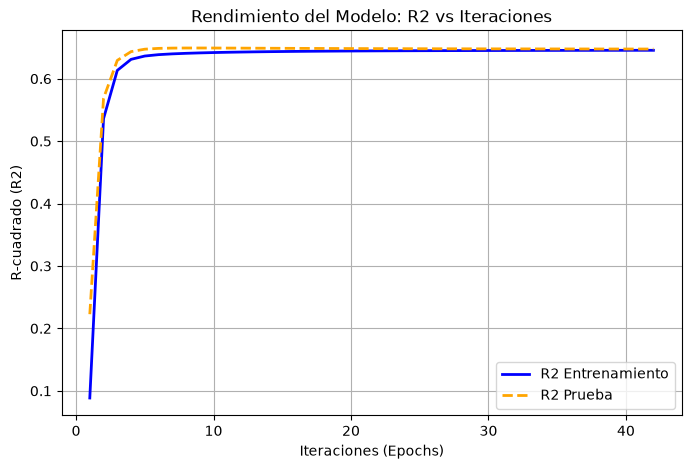

R2 final en datos de prueba tras 42 iteraciones: 0.6475


In [172]:
scaler = StandardScaler()
x_train_std = scaler.fit_transform(x_train)
x_test_std = scaler.transform(x_test)

modelo_sgd = SGDRegressor(random_state=42)

epochs = 42
r2_train = []
r2_test = []

for epoch in range(epochs):
    modelo_sgd.partial_fit(x_train_std, y_train)
    
    y_train_pred = modelo_sgd.predict(x_train_std)
    y_test_pred = modelo_sgd.predict(x_test_std)
    
    r2_train.append(r2_score(y_train, y_train_pred))
    r2_test.append(r2_score(y_test, y_test_pred))

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), r2_train, label='R2 Entrenamiento', color='blue', linewidth=2)
plt.plot(range(1, epochs + 1), r2_test, label='R2 Prueba', color='orange', linewidth=2, linestyle='--')

plt.title('Rendimiento del Modelo: R2 vs Iteraciones')
plt.xlabel('Iteraciones (Epochs)')
plt.ylabel('R-cuadrado (R2)')
plt.legend()
plt.grid(True)
plt.show()

print(f"R2 final en datos de prueba tras {epochs} iteraciones: {r2_test[-1]:.4f}")

Comparandolo a la regresion lineal, tienen resultados muy similares, lo unico que cambia es el proceso.
En cuanto al grafico, podemos observar que la proporcion de varianza es muy baja en las primeras iteraciones y luego a medida que van pasando las mismas, se va estabilizando hasta un punto en el que no cambia, indicando que encontro el punto optimo en los coeficientes y seguir iterando no va a mejorar el modelo.